# UK Rates & Inflation Dashboard

Tracks three things that move together in the UK economy: the 10-year gilt yield, a short-term interbank rate used here as a proxy for the Bank of England's Bank Rate, and CPI inflation measured against the Bank's 2% target.

### UK 10-year gilt yield

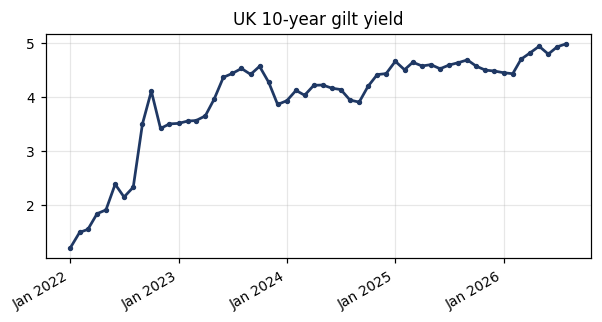

In [1]:
# chart

*Source: OECD long-term government bond yield series (IRLTLT01GBM156N), mirrored on FRED*

**Code:**
```python
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.plot(uk_gilt["date"], uk_gilt["gilt_10y_yield"], color="#1F3864", lw=1.8, marker="o", markersize=2.5)
ax.set_title("UK 10-year gilt yield", fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
```

**What this shows:**

The 10-year gilt yield is the interest rate the UK government effectively pays to borrow for a decade, and it sets the floor that everything else in sterling fixed income gets priced off — mortgage rates on longer fixes, corporate bond spreads, even how expensive it is for the Treasury to fund the deficit. It moves for two broad reasons: what the market expects the Bank Rate path to average over the next ten years, and a term premium investors demand for the uncertainty of holding UK government debt that long. A gilt yield that keeps climbing even after the Bank has started cutting Bank Rate is usually the market pricing in either stickier inflation further out, or concern about how much debt the UK is issuing to cover the deficit — the two aren't always easy to tell apart from the yield alone, which is part of why it's worth tracking against the inflation print below.

### UK 3-month interbank rate

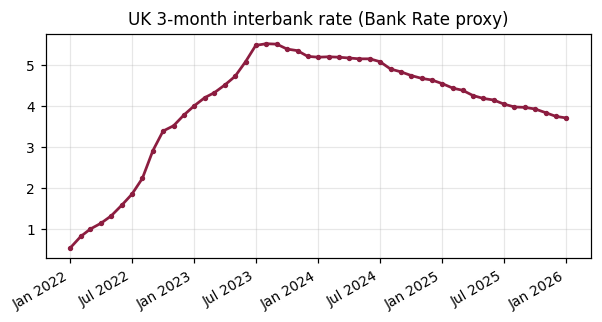

In [1]:
# chart

*Source: OECD 3-month interbank rate series (IR3TIB01GBM156N), mirrored on FRED*

**Code:**
```python
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.plot(uk_3m["date"], uk_3m["uk_3m_interbank_rate"], color="#8C1D40", lw=1.8, marker="o", markersize=2.5)
ax.set_title("UK 3-month interbank rate (Bank Rate proxy)", fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
```

**What this shows:**

This is the rate banks charge each other for short-term sterling funding, and it tracks the Bank of England's own Bank Rate closely enough to stand in for it here (no free, key-less feed of the Bank Rate itself was available — see the caveats below). It's the rate that actually filters through fastest into the real economy: tracker mortgages, business overdrafts, and short-dated savings rates all move with it more or less immediately, whereas the 10-year gilt above only really bites on new long-dated borrowing. Watching the gap between this short rate and the 10-year gilt is a rough read on whether the market expects the Bank to be cutting or holding over the next decade — a short rate well above the 10-year suggests the market expects cuts ahead; the two converging suggests it doesn't.

### UK CPI, year-on-year

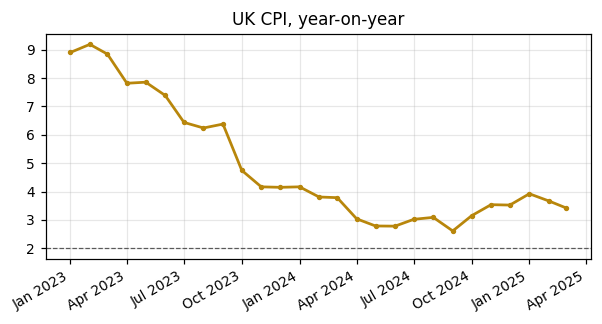

In [1]:
# chart

*Source: OECD CPI series (GBRCPIALLMINMEI), mirrored on FRED — last verified print: March 2025*

**Code:**
```python
uk_cpi["yoy"] = uk_cpi["cpi_index"].pct_change(12) * 100
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.plot(uk_cpi["date"], uk_cpi["yoy"], color="#B8860B", lw=1.8, marker="o", markersize=2.5)
ax.axhline(2.0, color="#595959", ls="--", lw=0.8)
ax.set_title("UK CPI, year-on-year", fontsize=11)
```

**What this shows:**

The dashed line is the Bank of England's 2% target. The gap between the CPI line and that target is what the Monetary Policy Committee is ultimately trying to close when it sets Bank Rate — inflation running persistently above target erodes real wages and squeezes household spending power even when nominal pay is rising, which is the exact tension behind the UK's well-documented wage-growth-versus-inflation debate (see the thematic note on this in the portfolio). A CPI print that's falling toward target supports the case for further Bank Rate cuts; one that stalls well above target is the standard argument for holding, or even reversing course.

## Caveats on the data behind this notebook

**UK CPI stops at March 2025.** The free OECD-mirrored series on FRED had not been updated further at the time this was pulled; a direct ONS API query was tried first and returned an empty payload for the series IDs attempted. Rather than estimate or carry the last value forward, the chart above simply stops at the last verified print and this gap is being named here rather than smoothed over.

**No standalone Bank Rate series was available** from a free, key-less endpoint in the time available for this build. The 3-month interbank rate — which tracks Bank Rate closely — is used as an explicit, labelled proxy instead, not as the real thing.